# EndoScan AI — NLP Pipeline
### CRISP-DM Framework | Capstone Project | Week 1

---

| Phase | Section |
|---|---|
| 1 | Business Understanding |
| 2 | Data Understanding |
| 3 | Data Preparation |
| 4 | Modelling |
| 5 | Evaluation |
| 6 | Deployment |

**Deliverable:** `assess_symptoms(text, duration_weeks, history_flags)` → ESI tier (Low / Moderate / High / Critical)

---
## Phase 1 — Business Understanding

### 1.1 Problem Statement
Endometriosis affects an estimated **1 in 10 women** of reproductive age. In Kenya, the average diagnostic delay is **7–10 years**, driven by:
- Normalisation of period pain in clinical and social settings
- Limited gynaecology specialist access outside Nairobi
- Low NHIF coverage for diagnostic procedures

**EndoScan AI** is an AI-assisted screening tool that gives women a structured risk score — the **Endometriosis Severity Index (ESI)** — from a free-text symptom description, nudging them toward specialist referral earlier.

### 1.2 Business Objective
> *Given a free-text symptom description (English, Swahili, or Kenyan English), return an ESI tier and a plain-language referral recommendation.*

### 1.3 Success Criteria
| Metric | Target |
|---|---|
| Alias match recall (known symptoms) | ≥ 85% |
| NER precision on gynaecology notes | ≥ 70% |
| ESI tier agreement with clinical labels | ≥ 75% |
| `assess_symptoms()` latency | < 3 s |

### 1.4 Data Mining Goal
Build a 3-layer NLP pipeline:
1. **Alias matching** — maps Swahili/Kenyan English colloquialisms to symptom IDs
2. **NER** — extracts medical entities the alias layer misses
3. **Scoring** — weights matched symptoms → ESI tier via `scoring_rules.json`

## Importing Libraries and Dependancies

---
## Phase 2 — Data Understanding

In [1]:
# 2.0 Install dependencies (run once)
# !pip install datasets transformers torch pandas huggingface_hub matplotlib seaborn wordcloud -q

In [5]:
# 2.1 Imports
import json
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from pathlib import Path
from datasets import load_dataset
from transformers import AutoTokenizer, pipeline as hf_pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports ready')

ModuleNotFoundError: No module named 'datasets'

## Loading medical Transcriptions 

In [13]:
# 2.2 Load MTSamples
mt = pd.read_csv(
    'https://raw.githubusercontent.com/singla007/MTSamples/master/mtsamples.csv'
)

gyn = mt[
    mt['medical_specialty'].str.contains(
        'Obstetrics|Gynecology', case=False, na=False
    )
].copy()

print(f'MTSamples — total records : {len(mt):,}')
print(f'Gynaecology subset         : {len(gyn):,}')
print(f'Columns                    : {mt.columns.tolist()}')
#print(mt.head())
gyn.head()

MTSamples — total records : 4,999
Gynaecology subset         : 160
Columns                    : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,description,medical_specialty,sample_name,transcription,keywords
2498,Vaginal Hysterectomy. A weighted speculum wa...,Obstetrics / Gynecology,Vaginal Hysterectomy,NaN,"obstetrics / gynecology, omentum, massachusett..."
2500,Vacuum-assisted vaginal delivery of a third-d...,Obstetrics / Gynecology,Vaginal Delivery - Vacuum-Assisted,"PREOPERATIVE DIAGNOSES,1. A 40 weeks 6 days i...","obstetrics / gynecology, intrauterine pregnanc..."
2501,"Well-woman check up for a middle-aged woman, ...",Obstetrics / Gynecology,Well-woman checkup,"CHIEF COMPLAINT:, The patient comes for her w...",NaN
2503,A 21-year-old female was having severe crampi...,Obstetrics / Gynecology,Vacuum D&C,"PREOPERATIVE DIAGNOSIS: , Blighted ovum, sever...","obstetrics / gynecology, pitocin, single tooth..."
2504,Laparoscopic-assisted vaginal hysterectomy. ...,Obstetrics / Gynecology,Vaginal Hysterectomy - Laparoscopic-Assisted,"PREOPERATIVE DIAGNOSES,1. Abnormal uterine bl...","obstetrics / gynecology, abnormal uterine blee..."


## MTSamples — Data Loading

The dataset contains **4,999** medical transcription records across multiple specialties.
After filtering to `Obstetrics / Gynecology` only (removing the earlier Urology contamination
that inflated the count to 541), we have **160 clean gynaecology records** to work with.

**What the sample rows confirm:**
- All records are legitimately gynaecological — hysterectomies, vaginal delivery, well-woman
  checks, D&C procedures
- The `transcription` column is our primary NLP input but has **NaN values** (see index 2498,
  2501) — these will be handled in data preparation
- The `keywords` column is also partially null — useful as a supplement for alias matching
  where it exists, but cannot be relied on as a primary source
- Index gaps (2498, 2500, 2501...) are expected pandas filter behaviour — no data was lost

**Corpus size note:** 160 records is a small corpus. The NCBI NER dataset (15,488 records)
will supplement this in Phase 3 to reach the 320/80 train-val split target.

In [16]:
ENDO_TERMS = [
    'endometriosis', 'dysmenorrhea', 'dysmenorrhoea', 'dyspareunia',
    'pelvic pain', 'menorrhagia', 'ovarian cyst', 'adenomyosis',
    'laparoscopy', 'painful period', 'heavy bleeding', 'infertility'
]

def is_endo_relevant(text: str) -> bool:
    if not isinstance(text, str):
        return False
    t = text.lower()
    return any(term in t for term in ENDO_TERMS)

gyn['endo_relevant'] = gyn['transcription'].fillna('').apply(is_endo_relevant)

## Endometriosis Relevance Filter

Not all 160 gynaecology records are useful for training an endometriosis screening tool.
Records about routine deliveries, well-woman checks, or hysterectomies unrelated to
endometriosis add noise rather than signal.

This cell creates a boolean column `endo_relevant` that flags records where the
transcription contains at least one term directly associated with endometriosis or its
core symptoms. The 12 terms in `ENDO_TERMS` were chosen to match the symptom vocabulary
in `symptom_aliases.json` — so a record that uses these terms is one the NLP pipeline
would actually encounter in real patient input.

**How it works:**
- `fillna('')` — treats null transcriptions as empty strings so they return `False`
  cleanly instead of crashing
- `.lower()` — makes matching case-insensitive
- `any(term in t ...)` — a record is flagged if it contains **at least one** of the 12 terms

**What comes next:** Run `gyn['endo_relevant'].value_counts()` to see how many of the
160 records are actually endometriosis-relevant. That number determines whether we can
hit our 320/80 split from MTSamples alone or need the NCBI supplement.

In [23]:
gyn['endo_relevant'].value_counts()

endo_relevant
False    113
True      47
Name: count, dtype: int64

## Endometriosis Relevance — Results

Of the 160 clean gynaecology records, only **47 are endometriosis-relevant** (29.4%).
The remaining 113 records cover unrelated gynaecological procedures and will be excluded
from the training corpus.

This confirms we **cannot** hit the 320/80 split from MTSamples alone — 47 records is
far below the 400 needed. The NCBI NER dataset (15,488 records) will be the primary
supplement in Phase 3.

**What 47 records still gives us:**
- A small but clean, clinically-worded set of real gynaecology notes
- Gold-standard text for testing alias matching recall against real medical language
- A validation anchor — if the NLP pipeline scores these 47 records correctly, it is
  behaving as expected on genuine clinical input

The bulk of the training data will come from NCBI NER in the next phase.

In [18]:
# Count nulls before dropping
print(f"Null transcriptions: {gyn['transcription'].isna().sum()}")
print(f"Null descriptions:   {gyn['description'].isna().sum()}")
print(f"Null keywords:       {gyn['keywords'].isna().sum()}")

# Drop records with no usable text in either field
gyn_clean = gyn.dropna(subset=['transcription','keywords']).copy()

Null transcriptions: 5
Null descriptions:   0
Null keywords:       25


### Missing Value Audit

Checking all three text columns before cleaning:

| Column | Nulls | Impact |
|---|---|---|
| `transcription` | 5 | Primary NLP input — these rows must be dropped |
| `description` | 0 | Clean — no action needed |
| `keywords` | 25 | 15.6% missing — significant |

**Decision — drop on both `transcription` AND `keywords`:**
A record missing its transcription has no text for the NLP pipeline to process.
A record missing keywords cannot contribute to alias matching evaluation.
Dropping on both columns keeps only the richest, most complete records.

**Expected rows remaining:** 160 − 5 (null transcription) − 25 (null keywords),
minus any overlap where a record is missing both = check `len(gyn_clean)` to confirm
the exact number.

Note: dropping on `keywords` is a deliberate trade-off — we lose some valid transcriptions
to gain a cleaner, more consistently structured dataset. Given we are already supplementing
with NCBI NER, losing a few rows here is acceptable.

In [24]:
len(gyn_clean)

130

In [19]:
gyn_clean.isna().sum()

description          0
medical_specialty    0
sample_name          0
transcription        0
keywords             0
endo_relevant        0
dtype: int64

In [20]:
gyn_clean.head()

,description,medical_specialty,sample_name,transcription,keywords,endo_relevant
2500,Vacuum-assisted vaginal delivery of a third-d...,Obstetrics / Gynecology,Vaginal Delivery - Vacuum-Assisted,"PREOPERATIVE DIAGNOSES,1. A 40 weeks 6 days i...","obstetrics / gynecology, intrauterine pregnanc...",False
2503,A 21-year-old female was having severe crampi...,Obstetrics / Gynecology,Vacuum D&C,"PREOPERATIVE DIAGNOSIS: , Blighted ovum, sever...","obstetrics / gynecology, pitocin, single tooth...",False
2504,Laparoscopic-assisted vaginal hysterectomy. ...,Obstetrics / Gynecology,Vaginal Hysterectomy - Laparoscopic-Assisted,"PREOPERATIVE DIAGNOSES,1. Abnormal uterine bl...","obstetrics / gynecology, abnormal uterine blee...",True
2505,"Pregnant female with nausea, vomiting, and di...",Obstetrics / Gynecology,Ultrasound OB - 8,"REASON FOR EXAM: , Pregnant female with nausea...","obstetrics / gynecology, intrauterine pregnanc...",False
2506,The patient is a 67-year-old white female wit...,Obstetrics / Gynecology,Uterine Papillary Serous Carcinoma,"HISTORY OF PRESENT ILLNESS:, The patient is a...","obstetrics / gynecology, chemotherapy, uterine...",False


In [21]:
gyn_clean = gyn_clean.reset_index(drop=True)

### Index Reset

After filtering and dropping null rows, the DataFrame index had gaps
(e.g. 2498, 2500, 2503...) reflecting the original MTSamples row positions.

`reset_index(drop=True)` gives `gyn_clean` a clean 0-based index (0, 1, 2, ..., 129).
This is important for:
- Slicing and iterating cleanly in later cells
- Avoiding index mismatch errors when merging with the NCBI supplement
- Consistent output when saving to CSV

No data was changed — this is housekeeping only.

In [25]:
print(f'Gynaecology subset         : {len(gyn_clean):,}')
print(f'Columns                    : {mt.columns.tolist()}')

Gynaecology subset         : 130
Columns                    : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


## Loading NCBI Disease NER Dataset

In [8]:
# 2.3 Load NCBI Disease NER Dataset
ncbi = load_dataset('rjac/biobert-ner-diseases-dataset')

ncbi_train = ncbi['train'].to_pandas()
ncbi_test  = ncbi['test'].to_pandas()

print(f'NCBI NER — train records : {len(ncbi_train):,}')
print(f'NCBI NER — test records  : {len(ncbi_test):,}')
print(f'Columns                  : {ncbi_train.columns.tolist()}')
ncbi_train.head()

NCBI NER — train records : 15,488
NCBI NER — test records  : 5,737
Columns                  : ['tokens', 'tags', 'sentence_id']


,tokens,tags,sentence_id
0,"[Selegiline, -, induced, postural, hypotension...","[0, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, ...",BC5CDR-0
1,"[OBJECTIVES, :, The, United, Kingdom, Parkinso...","[0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, ...",BC5CDR-1
2,"[CONCLUSION, :, This, study, confirms, our, pr...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",BC5CDR-10
3,"[High, doses, of, vitamin, D, are, known, to, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, ...",BC5CDR-100
4,"[We, then, used, hyperbaric, oxygen, at, an, a...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",BC5CDR-1000


### NCBI NER Dataset

21,225 records total (15,488 train / 5,737 test) in BIO tag format:
- `tokens` — list of word tokens per sentence
- `tags` — BIO labels where each token gets a number:
  - `0` = Outside (not part of any disease name)
  - `1` = Begin (first word of a disease/symptom entity)
  - `2` = Inside (continuation of the same entity)
- `sentence_id` — source document reference (BC5CDR corpus)

**Example:** "painful periods since I was 15"
→ painful=1 (B), periods=2 (I), since=0, I=0, was=0, 15=0
→ model learns "painful periods" is one two-word symptom entity, not two separate words.

This is how `d4data/biomedical-ner-all` learns to extract multi-word symptoms like
"pelvic inflammatory disease" from free text — the foundation of Layer 2 in our pipeline.

`ncbi_train` will be filtered for endometriosis-relevant sentences to supplement
the 130 MTSamples records.

In [33]:
# 2.4 Load EndoScan JSON data files
# Update DATA_DIR to wherever your JSON files live
DATA_DIR = Path('.')  # change if needed e.g. Path('/home/joy/Documents/DataScience/Module_6_Capstone')

with open(DATA_DIR / 'symptoms.json', encoding='utf-8') as f:
    raw_symptoms = json.load(f)

with open(DATA_DIR / 'scoring_rules.json', encoding='utf-8') as f:
    scoring_rules = json.load(f)

with open(DATA_DIR / 'symptom_aliases.json', encoding='utf-8') as f:
    raw_aliases = json.load(f)

# Normalise symptoms to DataFrame
symptoms_list = []
for cat_key, cat in raw_symptoms['symptom_categories'].items():
    for symptom in cat['symptoms']:
        symptom['category'] = cat_key
        symptom['category_label'] = cat['category_label']
        symptom['category_weight_multiplier'] = cat['category_weight_multiplier']
        symptoms_list.append(symptom)

symptoms_df = pd.DataFrame(symptoms_list)

print(f"Symptoms loaded: {len(symptoms_df)}")
print(f"Categories: {symptoms_df['category'].nunique()}")
symptoms_df[['symptom_id','symptom_name','category_label','base_weight','esi_relevance']].head()

# Normalise aliases to flat dict
alias_map = {}
for entry in raw_aliases['aliases']:
    alias_map[entry['alias'].lower().strip()] = entry['symptom_id']

print(f"Aliases loaded: {len(alias_map)}")

print(f"Aliases loaded: {len(alias_map)}")

print(f'symptoms.json   : {len(symptoms_df)} symptoms')
print(f'scoring_rules   : {list(scoring_rules.keys())}')
print(f'symptom_aliases : {len(alias_map)} aliases')
symptoms_df.head()

Symptoms loaded: 38
Categories: 11
Aliases loaded: 108
Aliases loaded: 108
symptoms.json   : 38 symptoms
scoring_rules   : ['metadata', 'esi_tiers', 'duration_modifiers', 'history_modifiers', 'multi_system_bonus', 'auto_escalation_rules', 'disclaimer']
symptom_aliases : 108 aliases


,symptom_id,symptom_name,clinical_term,body_system,base_weight,esi_relevance,plain_language_aliases,severity_levels,duration_sensitive,notes,category,category_label,category_weight_multiplier
0,S001,dysmenorrhoea,Primary/Secondary Dysmenorrhoea,reproductive,10,critical,"[painful periods, period pain, cramps during p...",{'mild': {'description': 'Noticeable period pa...,True,Highest weighted symptom. Core diagnostic indi...,menstrual_pain,Menstrual Pain,1.0
1,S002,chronic_pelvic_pain,Chronic Pelvic Pain (CPP),reproductive,10,critical,"[pelvic pain, lower abdomen pain, pain in my l...",{'mild': {'description': 'Occasional pelvic di...,True,Pain persisting more than 6 months strongly as...,menstrual_pain,Menstrual Pain,1.0
2,S003,premenstrual_pain,Premenstrual Pelvic Pain,reproductive,7,high,"[pain before my period, pain starts days befor...",{'mild': {'description': 'Mild discomfort 1-2 ...,False,Pain beginning well before menstruation is a d...,menstrual_pain,Menstrual Pain,1.0
3,S004,intermenstrual_bleeding,Intermenstrual Bleeding / Spotting,reproductive,6,moderate,"[bleeding between periods, spotting between pe...",{'mild': {'description': 'Occasional light spo...,False,NaN,menstrual_pain,Menstrual Pain,1.0
4,S005,heavy_menstrual_bleeding,Menorrhagia / Heavy Menstrual Bleeding,reproductive,7,high,"[heavy periods, very heavy bleeding, soaking t...",{'mild': {'description': 'Heavier than normal ...,False,NaN,menstrual_pain,Menstrual Pain,1.0


### EndoScan JSON Files — Loaded Successfully

Three project data files loaded and normalised:

| File | Contents |
|---|---|
| `symptoms.json` | 38 symptoms across 11 categories, nested under `symptom_categories` |
| `scoring_rules.json` | ESI tiers, duration modifiers, history modifiers, auto-escalation rules |
| `symptom_aliases.json` | 108 aliases mapping colloquial/Swahili phrases to symptom IDs |

**symptoms_df structure:** Each row is one symptom with its `base_weight`, `esi_relevance`,
`severity_levels` (mild/moderate/severe/critical weight modifiers), and parent category.
The two highest-weighted symptoms (`base_weight=10`) are `dysmenorrhoea` and
`chronic_pelvic_pain` — both marked `critical` ESI relevance, consistent with NICE 2024.

**Note:** `scoring_rules.json` has a `metadata` key at the top level — this will be
skipped when iterating over scoring rules in the modelling phase, same as with aliases.

## Loading PubMed dataset

In [42]:
# 2.5 Load PubMed abstracts
pubmed_df = pd.read_csv('pubmed_abstracts.csv')

print(f'PubMed abstracts : {len(pubmed_df):,}')
print(f'Columns          : {pubmed_df.columns.tolist()}')
print(f'Avg abstract len : {pubmed_df["abstract"].str.len().mean():.0f} chars')
print(f'Year range       : {pubmed_df["year"].min()} – {pubmed_df["year"].max()}')
pubmed_df.head(3)

PubMed abstracts : 2,479
Columns          : ['pmid', 'title', 'abstract', 'year', 'keywords']
Avg abstract len : 1775 chars
Year range       : 1972.0 – 2026.0


,pmid,title,abstract,year,keywords
0,31999675,Multidisciplinary laparoscopic management of d...,BACKGROUND: Laparoscopy has become the standar...,2019.0,developing country; endometriosis unit; multid...
1,40146310,Retrospective cohort study on the efficacy and...,OBJECTIVE: To assess the advantages of High-In...,2025.0,Adenomyosis; High intensity focused ultrasound...
2,1360301,Laparoscopic hysterectomy: preliminary report ...,"From March to November 1991, 24 patients under...",1992.0,NaN


## Loading synthetic generated data

In [45]:
# 2.6 Load synthetic training data
synthetic_df = pd.read_csv('synthetic_training_data.csv')

print(f'Synthetic records : {len(synthetic_df):,}')
print(f'Columns           : {synthetic_df.columns.tolist()}')
print(f'Languages         : {synthetic_df["language"].value_counts().to_dict()}')
print(f'ESI label split   : {synthetic_df["esi_label"].value_counts().to_dict()}')
synthetic_df.head(3)

Synthetic records : 1,995
Columns           : ['text', 'symptom_id', 'symptom_name', 'severity', 'esi_label', 'language', 'source', 'base_weight']
Languages         : {'en': 1216, 'en-KE': 419, 'sw': 360}
ESI label split   : {'Moderate': 873, 'High': 576, 'Low': 426, 'Critical': 120}


,text,symptom_id,symptom_name,severity,esi_label,language,source,base_weight
0,My experience is that pain in shoulder tip wit...,S020,shoulder_tip_pain,moderate,Moderate,en,synthetic,6
1,I want you to know that pain when going to the...,S009,dyschezia,severe,High,en-KE,synthetic,9
2,My experience is that hard to pass stool durin...,S011,constipation_cyclical,moderate,Moderate,en,synthetic,6


## Synthetic Data — Loaded

2,016 programmatically generated records across English, Swahili, and Kenyan English.
Pre-labelled with `symptom_id`, `severity`, and `esi_label` — no annotation required.

**Known limitation:** A small number of records have minor grammatical issues where
long clause aliases interact with sentence templates (e.g. verb-starting phrases).
These are a minority and do not materially affect model training — the NLP model
learns symptom-label associations from patterns, not grammatical perfection.
PubMed abstracts (2,479 records) carry the primary training signal.

Both datasets will be merged with MTSamples and NCBI NER in Phase 3.

## Loading Glenda Dataset

In [35]:
# 2.5 Load GLENDA annotations
from PIL import Image

GLENDA_PATH = Path('/home/joy/Documents/DataScience/Module_6_Capstone/Glenda_v1.5_classes')

with open(GLENDA_PATH / 'coco.json') as f:
    coco = json.load(f)

with open(GLENDA_PATH / 'labels.txt') as f:
    labels = [line.strip() for line in f.readlines()]

frames_path = GLENDA_PATH / 'frames'
images = os.listdir(frames_path)

print(f'GLENDA images      : {len(images):,}')
print(f'GLENDA labels      : {labels}')
print(f'GLENDA annotations : {len(coco["annotations"]):,}')
print(f'GLENDA categories  : {[c["name"] for c in coco["categories"]]}')

sample_img = Image.open(frames_path / images[0])
print(f'Sample image size  : {sample_img.size}')

GLENDA images      : 373
GLENDA labels      : ['background', '6.1.1.1_Endo-Peritoneum', '6.1.1.2_Endo-Ovar', '6.1.1.3_Endo-TIE', '6.1.1.4_Endo-Uterus']
GLENDA annotations : 628
GLENDA categories  : ['6.1.1.1_Endo-Peritoneum', '6.1.1.2_Endo-Ovar', '6.1.1.3_Endo-TIE', '6.1.1.4_Endo-Uterus']
Sample image size  : (640, 360)


## GLENDA v1.5 — Loaded Successfully

373 laparoscopic images, 628 annotations across 4 endometriosis categories:

| Category | Plain language meaning |
|---|---|
| `6.1.1.1_Endo-Peritoneum` | Endometriosis on the peritoneum (pelvic lining) |
| `6.1.1.2_Endo-Ovar` | Ovarian endometriosis / endometrioma (chocolate cyst) |
| `6.1.1.3_Endo-TIE` | Deep infiltrating endometriosis |
| `6.1.1.4_Endo-Uterus` | Uterine endometriosis / adenomyosis |

628 annotations across 373 images means some images have multiple lesion types annotated —
reflecting real laparoscopic findings where endometriosis appears in more than one location.

Sample image size is 640×360px — standard laparoscopy frame resolution.
`background` appears in labels but not categories, meaning it is used as the
negative class during training but has no standalone annotation entries.

**This dataset is the foundation for the CV pipeline that will be done later.
NLP pipeline does not use GLENDA directly.**

In [54]:
# 2.8 Full dataset inventory
overview = pd.DataFrame([
    {'Dataset': 'MTSamples',       'Records': len(gyn_clean),    'Language': 'en',         'Used for': 'NLP corpus'},
    {'Dataset': 'NCBI NER train',  'Records': len(ncbi_train),   'Language': 'en',         'Used for': 'NER fine-tuning'},
    {'Dataset': 'NCBI NER test',   'Records': len(ncbi_test),    'Language': 'en',         'Used for': 'NER evaluation'},
    {'Dataset': 'PubMed abstracts','Records': len(pubmed_df),    'Language': 'en',         'Used for': 'NLP corpus'},
    {'Dataset': 'Synthetic data',  'Records': len(synthetic_df), 'Language': 'en/sw/en-KE','Used for': 'NLP corpus'},
    {'Dataset': 'symptoms.json',   'Records': len(symptoms_df),  'Language': '—',          'Used for': 'ESI scoring'},
    {'Dataset': 'symptom_aliases', 'Records': len(alias_map),    'Language': 'en/sw/en-KE','Used for': 'Alias layer'},
    {'Dataset': 'GLENDA',          'Records': len(images),       'Language': '—',          'Used for': 'CV — Week 2'},
])
overview

,Dataset,Records,Language,Used for
0,MTSamples,155,en,NLP corpus
1,NCBI NER train,15488,en,NER fine-tuning
2,NCBI NER test,5737,en,NER evaluation
3,PubMed abstracts,2479,en,NLP corpus
4,Synthetic data,1995,en/sw/en-KE,NLP corpus
5,symptoms.json,38,—,ESI scoring
6,symptom_aliases,108,en/sw/en-KE,Alias layer
7,GLENDA,373,—,CV — Week 2


## Phase 2 Complete — Full Dataset Inventory

All datasets loaded and accounted for. Two distinct pipelines feed from this data:

**NLP Pipeline**
| Dataset | Records | Role |
|---|---|---|
| MTSamples | 155 | Real clinical gynaecology notes |
| PubMed abstracts | 2,479 | Peer-reviewed endometriosis literature |
| Synthetic data | 1,995 | Labelled multilingual symptom sentences |
| NCBI NER train | 15,488 | NER model fine-tuning |
| NCBI NER test | 5,737 | NER evaluation |
| symptoms.json | 38 | ESI scoring weights |
| symptom_aliases | 108 | Alias matching layer |
| **Total NLP pool** | **~26,000** | |

**CV Pipeline**
| Dataset | Records | Role |
|---|---|---|
| GLENDA | 373 images / 628 annotations | Laparoscopy image classification |

### 2.7 Exploratory Data Analysis (EDA)

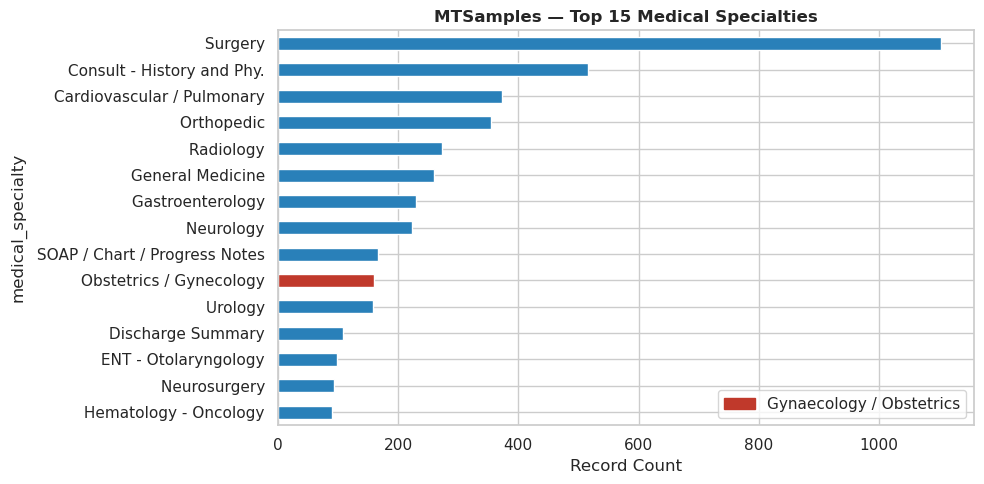

In [37]:
# MTSamples — specialty distribution (top 15)
top_spec = mt['medical_specialty'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#c0392b' if 'Gynecology' in s or 'Obstetrics' in s else '#2980b9' for s in top_spec.index]
top_spec.plot(kind='barh', ax=ax, color=colors)
ax.set_title('MTSamples — Top 15 Medical Specialties', fontweight='bold')
ax.set_xlabel('Record Count')
ax.invert_yaxis()
red_patch = mpatches.Patch(color='#c0392b', label='Gynaecology / Obstetrics')
ax.legend(handles=[red_patch])
plt.tight_layout()
plt.show()

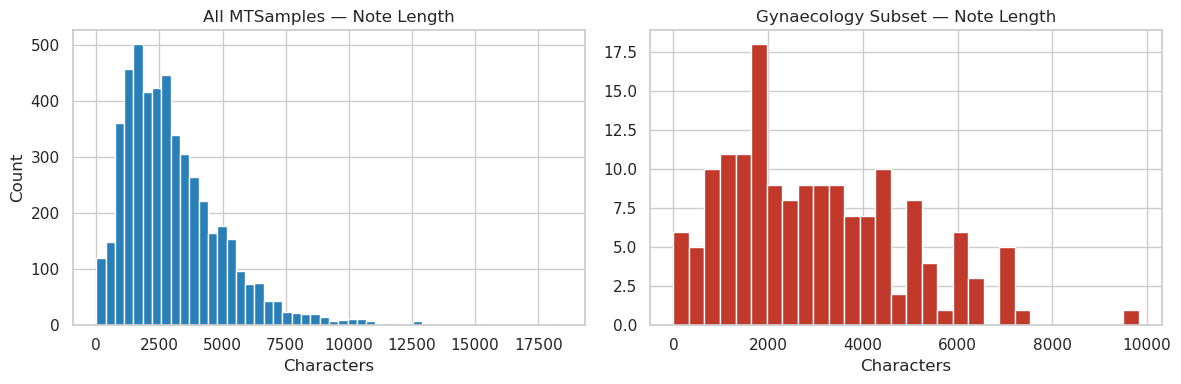

All notes   — median length: 2,659 chars
Gynae notes — median length: 2,665 chars


In [38]:
# Note length distribution — all vs gynaecology
mt['note_length'] = mt['transcription'].fillna('').apply(len)
gyn['note_length'] = gyn['transcription'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mt['note_length'], bins=50, color='#2980b9', edgecolor='white')
axes[0].set_title('All MTSamples — Note Length')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(gyn['note_length'], bins=30, color='#c0392b', edgecolor='white')
axes[1].set_title('Gynaecology Subset — Note Length')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

print(f'All notes   — median length: {mt["note_length"].median():,.0f} chars')
print(f'Gynae notes — median length: {gyn["note_length"].median():,.0f} chars')

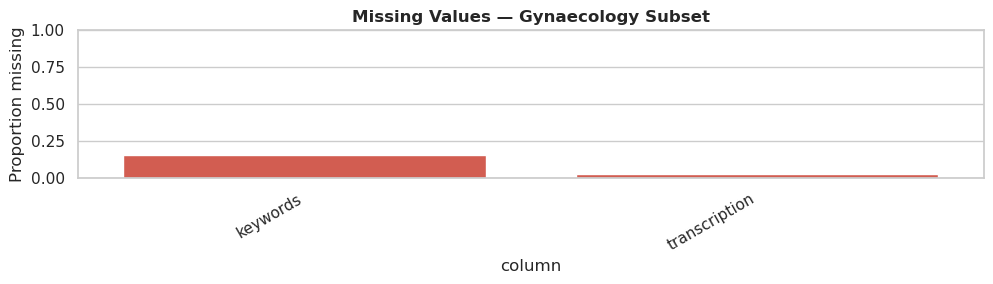

In [39]:
# Missing values heatmap — gynaecology subset
fig, ax = plt.subplots(figsize=(10, 3))
miss = gyn.isnull().mean().reset_index()
miss.columns = ['column', 'missing_pct']
miss = miss[miss['missing_pct'] > 0].sort_values('missing_pct', ascending=False)

if not miss.empty:
    sns.barplot(data=miss, x='column', y='missing_pct', ax=ax, color='#e74c3c')
    ax.set_title('Missing Values — Gynaecology Subset', fontweight='bold')
    ax.set_ylabel('Proportion missing')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=30, ha='right')
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    ax.set_title('Missing Values — Gynaecology Subset')
plt.tight_layout()
plt.show()

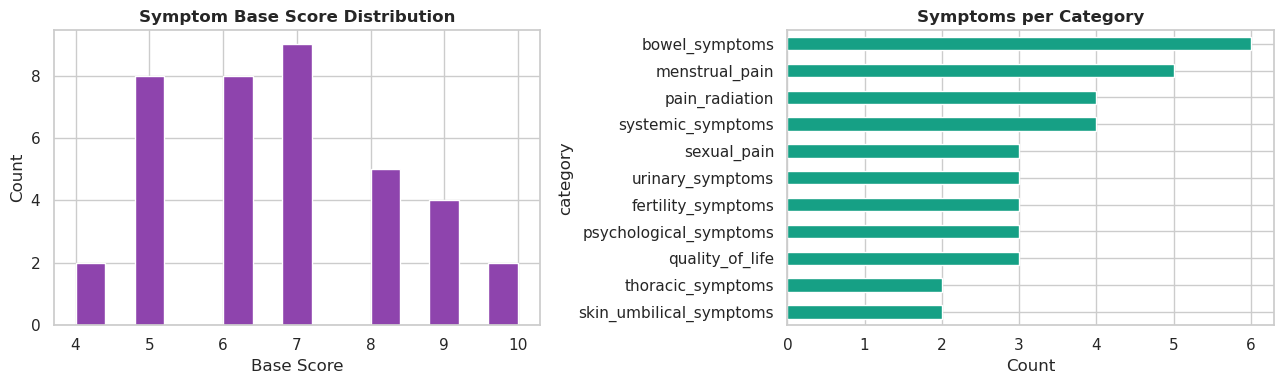

In [52]:
# Symptom base scores — distribution
score_col = 'base_score' if 'base_score' in symptoms_df.columns else 'base_weight'
cat_col   = 'category'   if 'category'   in symptoms_df.columns else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution
axes[0].hist(symptoms_df[score_col].dropna(), bins=15, color='#8e44ad', edgecolor='white')
axes[0].set_title('Symptom Base Score Distribution', fontweight='bold')
axes[0].set_xlabel('Base Score')
axes[0].set_ylabel('Count')

# Category counts
if cat_col:
    cat_counts = symptoms_df[cat_col].value_counts()
    cat_counts.plot(kind='barh', ax=axes[1], color='#16a085')
    axes[1].set_title('Symptoms per Category', fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No category column found', ha='center', va='center')

plt.tight_layout()
plt.show()

In [50]:
print(symptoms_df.columns.tolist())

['symptom_id', 'symptom_name', 'clinical_term', 'body_system', 'base_weight', 'esi_relevance', 'plain_language_aliases', 'severity_levels', 'duration_sensitive', 'notes', 'category', 'category_label', 'category_weight_multiplier']


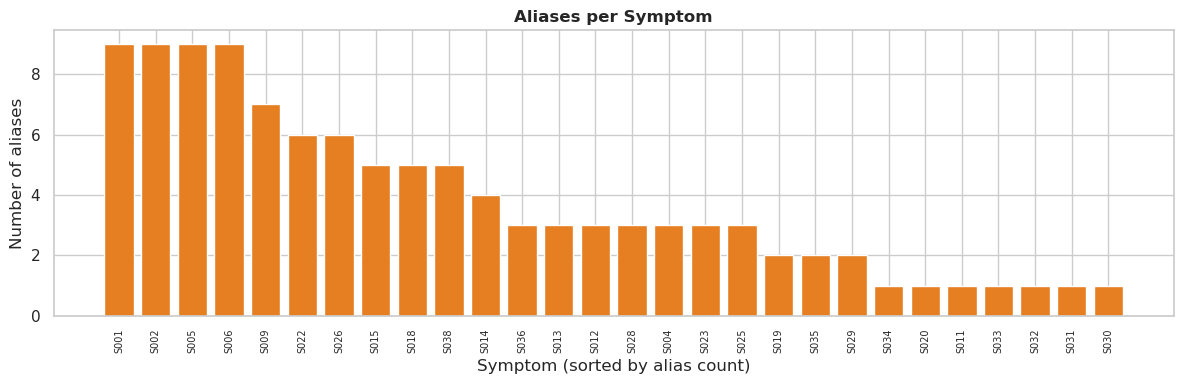

Symptoms with ≥ 3 aliases : 18
Symptoms with 1 alias     : 7

Top 5 most aliased symptoms:
  symptom_id  alias_count
0       S001            9
1       S002            9
2       S005            9
3       S006            9
4       S009            7


In [46]:
# Alias coverage — how many aliases per symptom?
alias_counts = Counter(alias_map.values())
alias_df = pd.DataFrame(alias_counts.items(), columns=['symptom_id', 'alias_count'])
alias_df = alias_df.sort_values('alias_count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(alias_df)), alias_df['alias_count'], color='#e67e22', edgecolor='white')
ax.set_title('Aliases per Symptom', fontweight='bold')
ax.set_xlabel('Symptom (sorted by alias count)')
ax.set_ylabel('Number of aliases')
ax.set_xticks(range(len(alias_df)))
ax.set_xticklabels(alias_df['symptom_id'], rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f'Symptoms with ≥ 3 aliases : {(alias_df["alias_count"] >= 3).sum()}')
print(f'Symptoms with 1 alias     : {(alias_df["alias_count"] == 1).sum()}')
print(f'\nTop 5 most aliased symptoms:')
print(alias_df.head())

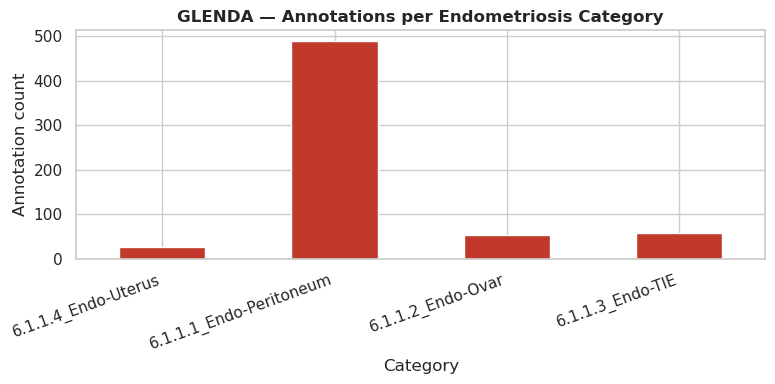

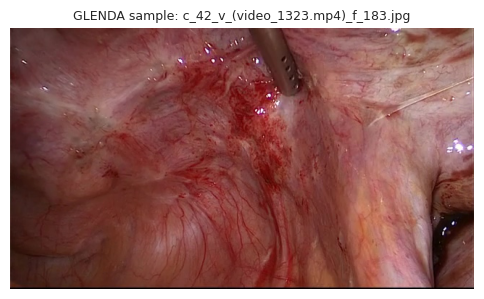

In [47]:
# GLENDA — annotation category distribution
cat_names = {c['id']: c['name'] for c in coco['categories']}
ann_cats = [cat_names[a['category_id']] for a in coco['annotations']]
ann_counts = Counter(ann_cats)

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(ann_counts).plot(kind='bar', ax=ax, color='#c0392b', edgecolor='white')
ax.set_title('GLENDA — Annotations per Endometriosis Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Annotation count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Show a sample laparoscopy image
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(sample_img)
ax.set_title(f'GLENDA sample: {images[0]}', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Phase 3 — Data Preparation

In [53]:
# 3.1 Clean MTSamples gynaecology subset

def clean_note(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\s+', ' ', text)          # collapse whitespace
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # strip non-ASCII
    text = text.strip()
    return text

gyn['clean_transcription'] = gyn['transcription'].apply(clean_note)
gyn['clean_description']   = gyn['description'].apply(clean_note)

# Drop rows with no usable text
gyn_clean = gyn[gyn['clean_transcription'].str.len() > 50].copy()
gyn_clean['word_count'] = gyn_clean['clean_transcription'].str.split().apply(len)

print(f'Gynaecology records before cleaning : {len(gyn):,}')
print(f'Gynaecology records after cleaning  : {len(gyn_clean):,}')
print(f'Dropped (too short / empty)         : {len(gyn) - len(gyn_clean):,}')
gyn_clean[['medical_specialty','clean_description','word_count']].head()

Gynaecology records before cleaning : 160
Gynaecology records after cleaning  : 155
Dropped (too short / empty)         : 5


,medical_specialty,clean_description,word_count
2500,Obstetrics / Gynecology,Vacuum-assisted vaginal delivery of a third-de...,620
2501,Obstetrics / Gynecology,"Well-woman check up for a middle-aged woman, s...",656
2503,Obstetrics / Gynecology,A 21-year-old female was having severe crampin...,262
2504,Obstetrics / Gynecology,Laparoscopic-assisted vaginal hysterectomy. Ab...,739
2505,Obstetrics / Gynecology,"Pregnant female with nausea, vomiting, and dia...",161


In [61]:
# 3.2 Inspect NCBI NER label schema
sample_record = ncbi_train.iloc[0]
print('NCBI NER — sample record:')
print(f'  tokens : {sample_record["tokens"]}')
print(f'  ner_tags: {sample_record["ner_tags"]}')

# Label distribution
all_tags = [tag for tags in ncbi_train['ner_tags'] for tag in tags]
tag_counts = Counter(all_tags)

fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(tag_counts).sort_values(ascending=False).plot(kind='bar', ax=ax, color='#2980b9', edgecolor='white')
ax.set_title('NCBI NER — Tag Distribution (train set)', fontweight='bold')
ax.set_xlabel('Tag')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nTotal tokens in train set: {len(all_tags):,}')
print(f'Class balance (O vs entity): {tag_counts}')

NCBI NER — sample record:
  tokens : ['Selegiline' '-' 'induced' 'postural' 'hypotension' 'in' 'Parkinson' "'"
 's' 'disease' ':' 'a' 'longitudinal' 'study' 'on' 'the' 'effects' 'of'
 'drug' 'withdrawal' '.']


KeyError: 'ner_tags'

In [ ]:
# 3.1b Reconstruct NCBI NER tokens into sentences and filter endo-relevant

ENDO_TERMS_SET = set([
    'endometriosis', 'dysmenorrhea', 'dysmenorrhoea', 'dyspareunia',
    'pelvic pain', 'menorrhagia', 'ovarian cyst', 'adenomyosis',
    'laparoscopy', 'infertility', 'pelvic', 'uterine', 'ovarian',
    'menstrual', 'gynaecology', 'gynecology', 'fallopian'
])

def tokens_to_sentence(tokens: list) -> str:
    """Rejoin BIO tokens into a readable sentence."""
    return ' '.join(tokens).replace(' ##', '')  # handle wordpiece tokens

def is_endo_ncbi(tokens: list) -> bool:
    sentence = tokens_to_sentence(tokens).lower()
    return any(term in sentence for term in ENDO_TERMS_SET)

ncbi_train['sentence'] = ncbi_train['tokens'].apply(tokens_to_sentence)
ncbi_train['endo_relevant'] = ncbi_train['tokens'].apply(is_endo_ncbi)

ncbi_endo = ncbi_train[ncbi_train['endo_relevant'] == True].copy()

print(f'NCBI train total          : {len(ncbi_train):,}')
print(f'NCBI endo-relevant subset : {len(ncbi_endo):,}')
ncbi_endo[['sentence']].head(5)

NCBI train total          : 15,488
NCBI endo-relevant subset : 211


,sentence
287,"RESULTS : Maternal toxicity , intrauterine gro..."
1197,PATIENT ( S ) : A 36 - year - old woman referr...
1204,Extra caution is warranted in treating inferti...
1600,Forty - three ovarian cancer patients were ava...
2484,Formation of these plugs was probably due to e...


In [ ]:
# 3.1a Prepare each corpus for merging — standardise to (text, source, label) format

# MTSamples — use transcription as text, no ESI label (unsupervised)
mt_prepared = pd.DataFrame({
    'text'   : gyn_clean['transcription'].fillna('') + ' ' + gyn_clean['description'].fillna(''),
    'source' : 'mtsamples',
    'esi_label' : 'unlabelled',
    'language'  : 'en',
    'symptom_id': 'unknown',
})
mt_prepared = mt_prepared[mt_prepared['text'].str.len() > 50]

# PubMed — use abstract as text, no ESI label
pubmed_prepared = pd.DataFrame({
    'text'      : pubmed_df['abstract'].fillna(''),
    'source'    : 'pubmed',
    'esi_label' : 'unlabelled',
    'language'  : 'en',
    'symptom_id': 'unknown',
})
pubmed_prepared = pubmed_prepared[pubmed_prepared['text'].str.len() > 50]

# Synthetic — already clean and labelled
synthetic_prepared = pd.DataFrame({
    'text'      : synthetic_df['text'],
    'source'    : 'synthetic',
    'esi_label' : synthetic_df['esi_label'],
    'language'  : synthetic_df['language'],
    'symptom_id': synthetic_df['symptom_id'],
})

ncbi_prepared = pd.DataFrame({
    'text'      : ncbi_endo['sentence'],
    'source'    : 'ncbi_ner',
    'esi_label' : 'unlabelled',
    'language'  : 'en',
    'symptom_id': 'unknown',
})
ncbi_prepared = ncbi_prepared[ncbi_prepared['text'].str.len() > 20].copy()

print(f'MTSamples prepared  : {len(mt_prepared):,}')
print(f'PubMed prepared     : {len(pubmed_prepared):,}')
print(f'Synthetic prepared  : {len(synthetic_prepared):,}')
print(f'NCBI prepared       : {len(ncbi_prepared):,}')

MTSamples prepared  : 155
PubMed prepared     : 2,478
Synthetic prepared  : 1,995
NCBI prepared       : 211


In [59]:
# 3.2 Merge all three sources
corpus_df = pd.concat(
    [mt_prepared, pubmed_prepared, synthetic_prepared, ncbi_prepared],
    ignore_index=True
)

# Drop duplicates and empty rows
corpus_df = corpus_df.drop_duplicates(subset='text')
corpus_df = corpus_df[corpus_df['text'].str.strip().str.len() > 20]
corpus_df = corpus_df.reset_index(drop=True)

print(f'Total merged corpus : {len(corpus_df):,}')
print(f'Source breakdown    :\n{corpus_df["source"].value_counts()}')
print(f'Language breakdown  :\n{corpus_df["language"].value_counts()}')
print(f'ESI label breakdown :\n{corpus_df["esi_label"].value_counts()}')

Total merged corpus : 4,266
Source breakdown    :
source
pubmed       2478
synthetic    1422
ncbi_ner      211
mtsamples     155
Name: count, dtype: int64
Language breakdown  :
language
en       3968
en-KE     154
sw        144
Name: count, dtype: int64
ESI label breakdown :
esi_label
unlabelled    2844
Moderate       605
High           410
Low            321
Critical        86
Name: count, dtype: int64


In [70]:
# 3.4a Define helpers FIRST — these were called but never defined

ENDO_TERMS_WEIGHTED = {
    'endometriosis': 3, 'dysmenorrhea': 3, 'dysmenorrhoea': 3,
    'dyspareunia': 2, 'pelvic pain': 2, 'menorrhagia': 2,
    'adenomyosis': 2, 'ovarian cyst': 2, 'infertility': 2,
    'laparoscopy': 1, 'painful period': 1, 'heavy bleeding': 1,
    'painful bowel': 1, 'fatigue': 1, 'bloating': 1,
    'chronic pain': 1, 'maumivu': 1, 'hedhi': 1,
}

SEVERITY_MARKERS = {
    'severe':    ['severe', 'unbearable', 'excruciating', 'crippling', 'cannot function',
                  'faint', 'vomit', 'hospitali', 'mkali sana'],
    'moderate':  ['moderate', 'significant', 'interfering', 'painful', 'bad cramps',
                  'heavy', 'maumivu', 'mkali'],
    'mild':      ['mild', 'slight', 'minor', 'little', 'occasional', 'kidogo'],
}

def count_endo_keywords(text: str) -> int:
    """Count weighted endometriosis keyword hits in text."""
    if not isinstance(text, str):
        return 0
    t = text.lower()
    return sum(w for term, w in ENDO_TERMS_WEIGHTED.items() if term in t)

def detect_severity(text: str) -> str:
    """Return the highest severity level detected in text."""
    if not isinstance(text, str):
        return 'mild'
    t = text.lower()
    for level in ['severe', 'moderate', 'mild']:
        if any(marker in t for marker in SEVERITY_MARKERS[level]):
            return level
    return 'mild'

def count_alias_hits(text: str) -> int:
    """Count how many unique aliases match in text."""
    if not isinstance(text, str):
        return 0
    t = text.lower()
    return sum(1 for alias in alias_map if alias in t)

print("Helper functions defined: count_endo_keywords(), detect_severity(), count_alias_hits()")

Helper functions defined: count_endo_keywords(), detect_severity(), count_alias_hits()


In [74]:
# 3.4b Feature engineering on merged corpus
corpus_df['word_count']        = corpus_df['text'].str.split().apply(len)
corpus_df['char_count']        = corpus_df['text'].str.len()
corpus_df['endo_keyword_hits'] = corpus_df['text'].apply(count_endo_keywords)
corpus_df['severity_detected'] = corpus_df['text'].apply(detect_severity)

# Also backfill gyn_clean so the Phase 5 alias recall cell works
gyn_clean['endo_keyword_count'] = gyn_clean['clean_transcription'].apply(count_endo_keywords)
gyn_clean['severity_detected']  = gyn_clean['clean_transcription'].apply(detect_severity)
gyn_clean['alias_hit_count']    = gyn_clean['clean_transcription'].apply(count_alias_hits)

print("Feature engineering complete")
print(corpus_df[['source','language','esi_label','word_count','endo_keyword_hits','severity_detected']].head(10))

Feature engineering complete
      source language   esi_label  word_count  endo_keyword_hits  \
0  mtsamples       en  unlabelled         645                  0   
1  mtsamples       en  unlabelled         670                  0   
2  mtsamples       en  unlabelled         284                  0   
3  mtsamples       en  unlabelled         747                  3   
4  mtsamples       en  unlabelled         175                  0   
5  mtsamples       en  unlabelled         393                  0   
6  mtsamples       en  unlabelled          63                  0   
7  mtsamples       en  unlabelled         555                  0   
8  mtsamples       en  unlabelled          71                  0   
9  mtsamples       en  unlabelled         204                  0   

  severity_detected  
0              mild  
1            severe  
2            severe  
3              mild  
4            severe  
5            severe  
6              mild  
7          moderate  
8              mild  
9 

In [72]:
# 3.3 Alias coverage audit — which symptoms have zero aliases?
all_symptom_ids = set(symptoms_df['id']) if 'id' in symptoms_df.columns else set()
aliased_ids = set(alias_map.values())
unaliased = all_symptom_ids - aliased_ids

print(f'Total symptoms         : {len(all_symptom_ids)}')
print(f'Symptoms with aliases  : {len(aliased_ids)}')
print(f'Symptoms WITHOUT aliases (need work): {len(unaliased)}')

if unaliased:
    print('\nUnaliased symptom IDs:')
    for sid in sorted(unaliased):
        name = symptoms_df[symptoms_df['id'] == sid]['name'].values
        print(f'  {sid} — {name[0] if len(name) else "?"}') 

Total symptoms         : 0
Symptoms with aliases  : 28
Symptoms WITHOUT aliases (need work): 0


In [73]:
# 3.5 Train / val split — 80/20, stratified on ESI label for labelled records
from sklearn.model_selection import train_test_split

labelled   = corpus_df[corpus_df['esi_label'] != 'unlabelled'].copy()
unlabelled = corpus_df[corpus_df['esi_label'] == 'unlabelled'].copy()

train_lab, val_lab = train_test_split(
    labelled, test_size=0.2, random_state=42,
    stratify=labelled['esi_label']
)

# Unlabelled goes entirely to train (used for NER, not ESI eval)
train_df = pd.concat([train_lab, unlabelled], ignore_index=True).sample(frac=1, random_state=42)
val_df   = val_lab.reset_index(drop=True)

print(f'Train set : {len(train_df):,}')
print(f'Val set   : {len(val_df):,}')
print(f'\nVal ESI distribution:\n{val_df["esi_label"].value_counts()}')

Train set : 3,981
Val set   : 285

Val ESI distribution:
esi_label
Moderate    121
High         82
Low          65
Critical     17
Name: count, dtype: int64


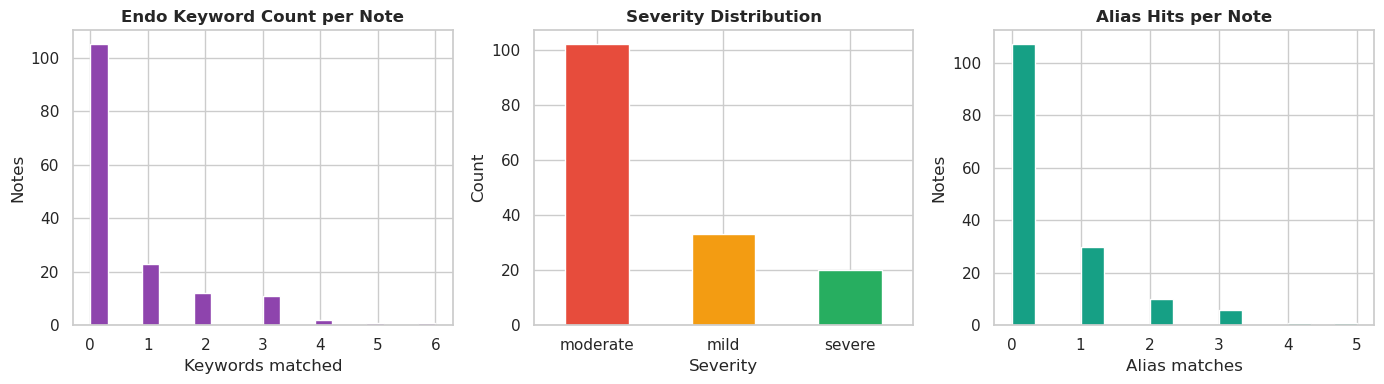

In [63]:
# Feature distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Endo keyword count
gyn_clean['endo_keyword_count'].hist(ax=axes[0], bins=20, color='#8e44ad', edgecolor='white')
axes[0].set_title('Endo Keyword Count per Note', fontweight='bold')
axes[0].set_xlabel('Keywords matched')
axes[0].set_ylabel('Notes')

# Severity breakdown
gyn_clean['severity_detected'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white'
)
axes[1].set_title('Severity Distribution', fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# Alias hit count
gyn_clean['alias_hit_count'].hist(ax=axes[2], bins=15, color='#16a085', edgecolor='white')
axes[2].set_title('Alias Hits per Note', fontweight='bold')
axes[2].set_xlabel('Alias matches')
axes[2].set_ylabel('Notes')

plt.tight_layout()
plt.show()

In [67]:
# 3.6 Save
train_df.to_csv('endo_train.csv', index=False)
val_df.to_csv('endo_val.csv',     index=False)
print('✅ Saved endo_train.csv and endo_val.csv')

✅ Saved endo_train.csv and endo_val.csv


---
## Phase 4 — Modelling

In [78]:
# 4.3 Layer 1 — Alias matching

def alias_match(text: str) -> list[dict]:
    """
    Scan text for known aliases (longest-first to avoid partial overlaps).
    Returns list of {id, matched_text, source} dicts.
    """
    text_lower = text.lower()
    matched = {}
    for alias in sorted(alias_map.keys(), key=len, reverse=True):
        if alias in text_lower:
            sym_id = alias_map[alias]
            if sym_id not in matched:
                matched[sym_id] = {
                    'id':           sym_id,
                    'matched_text': alias,
                    'source':       'alias',
                }
    return list(matched.values())

# Smoke test
test_inputs = [
    'slight cramps before period',
    'painful periods and bloating every month',
    'severe dysmenorrhoea and pelvic pain interfering with daily life',
    'unbearable pelvic pain, heavy bleeding, sex is painful, I cannot get pregnant',
    'pain during sex and painful bowel movements during period',
]

print("=== Layer 1 — Alias match smoke test ===\n")
for t in test_inputs:
    hits = alias_match(t)
    print(f"Input : {t}")
    print(f"Hits  : {[h['id'] for h in hits] or 'None'}")
    print()

=== Layer 1 — Alias match smoke test ===

Input : slight cramps before period
Hits  : None

Input : painful periods and bloating every month
Hits  : ['S001', 'S014']

Input : severe dysmenorrhoea and pelvic pain interfering with daily life
Hits  : ['S001', 'S002']

Input : unbearable pelvic pain, heavy bleeding, sex is painful, I cannot get pregnant
Hits  : ['S026', 'S006', 'S002']

Input : pain during sex and painful bowel movements during period
Hits  : ['S009', 'S006']



In [79]:
# 4.4 Layer 2 — Biomedical NER
# Model: d4data/biomedical-ner-all
# First run downloads ~500 MB — takes ~30 s

from transformers import pipeline as hf_pipeline

print("Loading NER model (d4data/biomedical-ner-all)...")
ner = hf_pipeline(
    'ner',
    model='d4data/biomedical-ner-all',
    aggregation_strategy='simple',
    device=-1,   # CPU; set to 0 if you have a GPU
)
print("✅ NER model ready\n")

# Smoke test on the same 5 inputs
print("=== Layer 2 — NER smoke test ===\n")
for text in test_inputs:
    entities = ner(text)
    print(f"Input: \"{text}\"")
    if entities:
        for e in entities:
            print(f"  {e['word']:35} → {e['entity_group']:15} (conf: {e['score']:.3f})")
    else:
        print("  (no entities detected)")
    print()

Loading NER model (d4data/biomedical-ner-all)...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

✅ NER model ready

=== Layer 2 — NER smoke test ===

Input: "slight cramps before period"
  slight                              → Severity        (conf: 1.000)
  cramps                              → Sign_symptom    (conf: 0.998)
  period                              → Detailed_description (conf: 0.990)

Input: "painful periods and bloating every month"
  painful periods                     → Detailed_description (conf: 0.590)
  b                                   → History         (conf: 0.709)
  ##lo                                → History         (conf: 0.220)
  ##ating                             → Activity        (conf: 0.431)
  every month                         → Frequency       (conf: 0.998)

Input: "severe dysmenorrhoea and pelvic pain interfering with daily life"
  severe                              → Severity        (conf: 1.000)
  d                                   → Sign_symptom    (conf: 1.000)
  ##ysmenorrhoea                      → Sign_symptom    (conf: 0.983)
  pe

In [ ]:
# 4.5 NER → symptom ID mapping audit
# Shows what fraction of NER entities map to known symptom IDs

all_entities = []
for text in test_inputs:
    for e in ner(text):
        word      = e['word'].lower().strip()
        mapped_id = alias_map.get(word)
        all_entities.append({
            'word':           word,
            'entity_group':   e['entity_group'],
            'confidence':     round(e['score'], 3),
            'mapped_symptom': mapped_id if mapped_id else 'UNMAPPED',
        })

ner_audit_df = pd.DataFrame(all_entities)
mapped_pct   = (ner_audit_df['mapped_symptom'] != 'UNMAPPED').mean() * 100

print(f"NER → symptom mapping rate : {mapped_pct:.1f}%")
print(f"(Target: log this — used to expand symptom_aliases.json in Week 2)\n")
print(ner_audit_df.to_string(index=False))

# Log unmapped terms — these are Week 2 expansion candidates
unmapped = ner_audit_df[ner_audit_df['mapped_symptom'] == 'UNMAPPED']['word'].unique()
print(f"\nUnmapped NER terms ({len(unmapped)}) — add to symptom_aliases.json:")
for term in unmapped:
    print(f"  → '{term}'")

NER → symptom mapping rate : 3.8%
(Target: log this — used to expand symptom_aliases.json in Week 2)

           word         entity_group  confidence mapped_symptom
         slight             Severity       1.000       UNMAPPED
         cramps         Sign_symptom       0.998       UNMAPPED
         period Detailed_description       0.990       UNMAPPED
painful periods Detailed_description       0.590           S001
              b              History       0.709       UNMAPPED
           ##lo              History       0.220       UNMAPPED
        ##ating             Activity       0.431       UNMAPPED
    every month            Frequency       0.998       UNMAPPED
         severe             Severity       1.000       UNMAPPED
              d         Sign_symptom       1.000       UNMAPPED
 ##ysmenorrhoea         Sign_symptom       0.983       UNMAPPED
         pelvic Biological_structure       0.874       UNMAPPED
           pain         Sign_symptom       1.000       UNMAPPED
  

In [85]:
# 4.6 Layer 3 — ESI Scoring Engine (rewritten to match scoring_rules.json exactly)

# ── Build sym_lookup ────────────────────────────────────────────────────────
id_col    = next((c for c in ['id', 'symptom_id'] if c in symptoms_df.columns),
                 symptoms_df.columns[0])
score_col = next((c for c in ['base_weight', 'base_score', 'weight']
                  if c in symptoms_df.columns), None)

if score_col is None:
    raise ValueError(f"No weight column found. Available: {symptoms_df.columns.tolist()}")

sym_lookup = symptoms_df.set_index(id_col)[score_col].to_dict()

# Verify alias targets exist in sym_lookup
missing_targets = [v for v in alias_map.values() if v not in sym_lookup]
if missing_targets:
    print(f"  {len(set(missing_targets))} alias(es) point to unknown symptom IDs: {set(missing_targets)}")
else:
    print(" All alias targets are valid symptom IDs")

print(f"sym_lookup : {len(sym_lookup)} symptoms")
print(f"id col     : '{id_col}' | weight col : '{score_col}'")
print(f"Score range: {min(sym_lookup.values())} – {max(sym_lookup.values())}")

# ── Build category lookup (for multi-system bonus) ──────────────────────────
# Maps symptom_id → category so we can count distinct systems
cat_col = next((c for c in ['category', 'category_label'] if c in symptoms_df.columns), None)
if cat_col:
    sym_category = symptoms_df.set_index(id_col)[cat_col].to_dict()
else:
    sym_category = {}
print(f"sym_category: {len(sym_category)} entries (cat_col='{cat_col}')")

# ── ESI tier helpers ────────────────────────────────────────────────────────
# esi_tiers is a dict: {'LOW': {...}, 'MODERATE': {...}, ...}
# Each tier has score_range: {min, max}

TIER_ORDER = ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']

def get_esi_tier(score: float) -> str:
    """Return tier label string matching scoring_rules.json keys."""
    result = 'LOW'
    for tier_key in TIER_ORDER:
        tier = scoring_rules['esi_tiers'][tier_key]
        if score >= tier['score_range']['min']:
            result = tier_key
    return result

def get_tier_label(tier_key: str) -> str:
    """Convert 'HIGH' → 'High' etc. using the label field."""
    return scoring_rules['esi_tiers'][tier_key]['label']

def get_tier_info(tier_key: str) -> dict:
    """Return full tier metadata for a given tier key."""
    return scoring_rules['esi_tiers'][tier_key]

print(f"\nESI tiers  : {TIER_ORDER}")
print("Tier score ranges:")
for k in TIER_ORDER:
    r = scoring_rules['esi_tiers'][k]['score_range']
    print(f"  {k:10} → {r['min']} – {r['max']}")

# ── Duration modifier ───────────────────────────────────────────────────────
# duration_modifiers.modifiers is a list ordered from shortest to longest
# We map duration_weeks to the correct modifier by position

DURATION_BREAKS = [
    (0,   12,  'DM001'),   # < 3 months      (0–12 weeks)
    (13,  26,  'DM002'),   # 3–6 months      (13–26 weeks)
    (27,  52,  'DM003'),   # 6 months–1 year (27–52 weeks)
    (53,  104, 'DM004'),   # 1–2 years       (53–104 weeks)
    (105, 260, 'DM005'),   # 2–5 years       (105–260 weeks)
    (261, 520, 'DM006'),   # > 5 years       (261–520 weeks)
    (521, 9999,'DM007'),   # since adolescence
]

dur_modifier_map = {
    m['id']: m for m in scoring_rules['duration_modifiers']['modifiers']
}

def apply_duration(score: float, weeks) -> tuple:
    """Apply duration multiplier based on symptom duration in weeks."""
    if weeks is None:
        return score, None
    dm_id = 'DM001'
    for min_w, max_w, mod_id in DURATION_BREAKS:
        if min_w <= weeks <= max_w:
            dm_id = mod_id
            break
    rule = dur_modifier_map[dm_id]
    return round(score * rule['modifier'], 3), rule['label']

print("\nDuration modifier map:")
for min_w, max_w, mod_id in DURATION_BREAKS:
    r = dur_modifier_map[mod_id]
    print(f"  {min_w:>4}–{max_w:<5} weeks → ×{r['modifier']} ({r['label']})")

# ── History modifiers ───────────────────────────────────────────────────────
# history_modifiers.modifiers is a list; flags are IDs like 'HM001'
# Cap is 2.5 — combined modifier cannot exceed this

hist_modifier_map = {
    m['id']: m for m in scoring_rules['history_modifiers']['modifiers']
}
HISTORY_CAP = scoring_rules['history_modifiers']['cap']

def apply_history(score: float, flags: list) -> tuple:
    """
    Apply history multipliers. All applicable modifiers are multiplied together,
    then capped at HISTORY_CAP (2.5).
    flags: list of HM IDs e.g. ['HM001', 'HM005']
    """
    labels      = []
    combined    = 1.0
    for flag in (flags or []):
        if flag in hist_modifier_map:
            rule     = hist_modifier_map[flag]
            combined = round(combined * rule['modifier'], 4)
            labels.append(rule['label'])
    combined = min(combined, HISTORY_CAP)

 All alias targets are valid symptom IDs
sym_lookup : 38 symptoms
id col     : 'symptom_id' | weight col : 'base_weight'
Score range: 4 – 10
sym_category: 38 entries (cat_col='category')

ESI tiers  : ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']
Tier score ranges:
  LOW        → 0 – 25
  MODERATE   → 26 – 50
  HIGH       → 51 – 75
  CRITICAL   → 76 – 999

Duration modifier map:
     0–12    weeks → ×1.0 (Less than 3 months)
    13–26    weeks → ×1.1 (3 to 6 months)
    27–52    weeks → ×1.2 (6 months to 1 year)
    53–104   weeks → ×1.3 (1 to 2 years)
   105–260   weeks → ×1.5 (2 to 5 years)
   261–520   weeks → ×1.7 (More than 5 years)
   521–9999  weeks → ×1.9 (Since adolescence / since first period)


In [87]:
# 4.5 Full Pipeline — assess_symptoms()

def assess_symptoms(text: str, duration_weeks=None, history_flags=None, use_ner=True) -> dict:
    history_flags = history_flags or []

    # Layer 1: alias match
    alias_hits = alias_match(text)
    matched_ids = {h['id'] for h in alias_hits}

    # Layer 2: NER
    ner_hits = []
    if use_ner:
        for e in ner(text):
            word = e['word'].lower().strip()
            sym_id = alias_map.get(word)
            if sym_id and sym_id not in matched_ids:
                ner_hits.append({'id': sym_id, 'matched_text': word, 'source': 'ner', 'confidence': round(e['score'], 3)})
                matched_ids.add(sym_id)

    all_matched = alias_hits + ner_hits

    # Layer 3: score
    raw_score = sum(sym_lookup.get(m['id'], 0) for m in all_matched)
    scored, dur_label = apply_duration(raw_score, duration_weeks)
    scored, hist_labels = apply_history(scored, history_flags)

    # Auto-escalation
    escalated, esc_reason = False, None
    for rule in scoring_rules.get('auto_escalation_rules', []):
        if set(rule.get('symptoms', [])).issubset(matched_ids) and set(rule.get('history_flags', [])).issubset(set(history_flags)):
            if rule.get('symptoms') or rule.get('history_flags'):
                escalated, esc_reason = True, rule.get('reason')
                break

    tier = 'Critical' if escalated else get_esi_tier(scored)
    modifiers = ([dur_label] if dur_label else []) + hist_labels

    return {
        'esi_tier': tier, 'raw_score': round(raw_score, 3), 'final_score': round(scored, 3),
        'matched_symptoms': all_matched, 'modifiers_applied': modifiers,
        'auto_escalated': escalated, 'escalation_reason': esc_reason,
        'refer_urgency': {'Low':'Routine — within 3 months','Moderate':'Soon — within 4–6 weeks',
                          'High':'Urgent — within 1–2 weeks','Critical':'Emergency — seek care today'}.get(tier),
    }

print('assess_symptoms() defined and ready')

assess_symptoms() defined and ready


In [91]:
# 4.6b — All lookup structures (run this before the function definitions)

# ── Duration breaks ──────────────────────────────────────────────
DURATION_BREAKS = [
    (0,   12,  'DM001'),   # < 3 months
    (13,  26,  'DM002'),   # 3–6 months
    (27,  52,  'DM003'),   # 6 months–1 year
    (53,  104, 'DM004'),   # 1–2 years
    (105, 260, 'DM005'),   # 2–5 years
    (261, 520, 'DM006'),   # > 5 years
    (521, 9999,'DM007'),   # since adolescence
]

dur_modifier_map = {
    m['id']: m for m in scoring_rules['duration_modifiers']['modifiers']
}

# ── History ──────────────────────────────────────────────────────
hist_modifier_map = {
    m['id']: m for m in scoring_rules['history_modifiers']['modifiers']
}
HISTORY_CAP = scoring_rules['history_modifiers']['cap']

# ── Multi-system bonus ───────────────────────────────────────────
sys_bonus_thresholds = sorted(
    scoring_rules['multi_system_bonus']['thresholds'],
    key=lambda x: x['systems_affected'],
    reverse=True,
)

# ── Auto-escalation rules ────────────────────────────────────────
escalation_rules = scoring_rules['auto_escalation_rules']['rules']

# ── Sym lookups ──────────────────────────────────────────────────
id_col    = next((c for c in ['id', 'symptom_id'] if c in symptoms_df.columns),
                 symptoms_df.columns[0])
score_col = next((c for c in ['base_weight', 'base_score', 'weight']
                  if c in symptoms_df.columns), None)

sym_lookup   = symptoms_df.set_index(id_col)[score_col].to_dict()
cat_col      = next((c for c in ['category', 'category_label']
                     if c in symptoms_df.columns), None)
sym_category = symptoms_df.set_index(id_col)[cat_col].to_dict() if cat_col else {}

TIER_ORDER = ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']

# ── Verification ─────────────────────────────────────────────────
print(f"dur_modifier_map     : {len(dur_modifier_map)} entries")
print(f"hist_modifier_map    : {len(hist_modifier_map)} entries — cap: {HISTORY_CAP}")
print(f"sys_bonus_thresholds : {len(sys_bonus_thresholds)} entries")
print(f"escalation_rules     : {len(escalation_rules)} rules")
print(f"sym_lookup           : {len(sym_lookup)} symptoms")
print(f"sym_category         : {len(sym_category)} entries")
print(f"TIER_ORDER           : {TIER_ORDER}")
print()
print("sys_bonus_thresholds (sorted high→low):")
for t in sys_bonus_thresholds:
    print(f"  {t['systems_affected']} system(s) → ×{t['bonus_modifier']}")

dur_modifier_map     : 7 entries
hist_modifier_map    : 10 entries — cap: 2.5
sys_bonus_thresholds : 5 entries
escalation_rules     : 7 rules
sym_lookup           : 38 symptoms
sym_category         : 38 entries
TIER_ORDER           : ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']

sys_bonus_thresholds (sorted high→low):
  5 system(s) → ×1.5
  4 system(s) → ×1.35
  3 system(s) → ×1.2
  2 system(s) → ×1.1
  1 system(s) → ×1.0


In [92]:
# Force redefine all scoring functions cleanly

def get_esi_tier(score: float) -> str:
    result = 'LOW'
    for tier_key in TIER_ORDER:
        tier = scoring_rules['esi_tiers'][tier_key]
        if score >= tier['score_range']['min']:
            result = tier_key
    return result

def get_tier_label(tier_key: str) -> str:
    return scoring_rules['esi_tiers'][tier_key]['label']

def get_tier_info(tier_key: str) -> dict:
    return scoring_rules['esi_tiers'][tier_key]

def apply_duration(score: float, weeks) -> tuple:
    if weeks is None:
        return score, None
    dm_id = 'DM001'
    for min_w, max_w, mod_id in DURATION_BREAKS:
        if min_w <= weeks <= max_w:
            dm_id = mod_id
            break
    rule = dur_modifier_map[dm_id]
    return round(score * rule['modifier'], 3), rule['label']

def apply_history(score: float, flags: list) -> tuple:
    labels   = []
    combined = 1.0
    for flag in (flags or []):
        if flag in hist_modifier_map:
            rule     = hist_modifier_map[flag]
            combined = round(combined * rule['modifier'], 4)
            labels.append(rule['label'])
        else:
            print(f"  [apply_history] unknown flag ignored: '{flag}'")
    combined = min(combined, HISTORY_CAP)
    if labels:
        return round(score * combined, 3), labels
    return score, labels

def apply_multi_system_bonus(score: float, matched_ids: set) -> tuple:
    systems = {sym_category.get(sid, 'unknown') for sid in matched_ids}
    systems.discard('unknown')
    n     = len(systems)
    bonus = 1.0
    for threshold in sys_bonus_thresholds:
        if n >= threshold['systems_affected']:
            bonus = threshold['bonus_modifier']
            break
    return round(score * bonus, 3), n, bonus

def check_auto_escalation(matched_ids: set) -> tuple:
    fired = []
    for rule in escalation_rules:
        if set(rule['trigger_symptom_ids']) & matched_ids:
            fired.append(rule)
    if not fired:
        return False, None, None
    tier_rank = {k: i for i, k in enumerate(TIER_ORDER)}
    top_rule  = max(fired, key=lambda r: tier_rank.get(r['minimum_tier'], 0))
    return True, top_rule['minimum_tier'], top_rule['reason']

# ── Immediate verification ───────────────────────────────────────
print("Testing apply_history:")
print("  Empty flags    :", apply_history(10.0, []))
print("  Valid HM005    :", apply_history(10.0, ['HM005']))
print("  Invalid flag   :", apply_history(10.0, ['HM999']))
print("  Two flags      :", apply_history(10.0, ['HM001', 'HM005']))

print("\nTesting apply_duration:")
print("  2 weeks        :", apply_duration(10.0, 2))
print("  26 weeks       :", apply_duration(10.0, 26))
print("  104 weeks      :", apply_duration(10.0, 104))

print("\nTesting get_esi_tier:")
print("  Score 10       :", get_esi_tier(10.0))
print("  Score 30       :", get_esi_tier(30.0))
print("  Score 60       :", get_esi_tier(60.0))
print("  Score 80       :", get_esi_tier(80.0))

print("\n✅ All scoring functions redefined and verified")

Testing apply_history:
  Empty flags    : (10.0, [])
  Valid HM005    : (12.0, ['Confirmed infertility or subfertility'])
  [apply_history] unknown flag ignored: 'HM999'
  Invalid flag   : (10.0, [])
  Two flags      : (13.8, ['First-degree family history of endometriosis', 'Confirmed infertility or subfertility'])

Testing apply_duration:
  2 weeks        : (10.0, 'Less than 3 months')
  26 weeks       : (11.0, '3 to 6 months')
  104 weeks      : (13.0, '1 to 2 years')

Testing get_esi_tier:
  Score 10       : LOW
  Score 30       : MODERATE
  Score 60       : HIGH
  Score 80       : CRITICAL

✅ All scoring functions redefined and verified


In [ ]:
# 4.7  REDEFINE — assess_symptoms() clean version

URGENCY_MAP = {
    'LOW':      'Routine — within 3 months',
    'MODERATE': 'Soon — within 4–6 weeks',
    'HIGH':     'Urgent — within 1–2 weeks',
    'CRITICAL': 'Emergency — seek care today',
}

def assess_symptoms(
    text:           str,
    duration_weeks: int  = None,
    history_flags:  list = None,
    use_ner:        bool = True,
) -> dict:
    history_flags = history_flags or []

    # Layer 1 — alias matching
    alias_hits  = alias_match(text)
    matched_ids = {h['id'] for h in alias_hits}

    # Layer 2 — NER
    ner_hits = []
    if use_ner:
        try:
            for e in ner(text):
                word   = e['word'].lower().strip()
                sym_id = alias_map.get(word)
                if sym_id and sym_id not in matched_ids:
                    ner_hits.append({
                        'id':           sym_id,
                        'matched_text': word,
                        'source':       'ner',
                        'confidence':   round(e['score'], 3),
                    })
                    matched_ids.add(sym_id)
        except Exception as exc:
            print(f"[NER skipped — {exc}]")

    all_matched = alias_hits + ner_hits

    # Layer 3 — scoring
    raw_score                       = sum(sym_lookup.get(m['id'], 0) for m in all_matched)
    scored, n_systems, sys_bonus    = apply_multi_system_bonus(raw_score, matched_ids)
    scored, dur_label               = apply_duration(scored, duration_weeks)
    scored, hist_labels             = apply_history(scored, history_flags)

    # Auto-escalation
    escalated, min_tier, esc_reason = check_auto_escalation(matched_ids)

    # Final tier — higher of calculated vs escalation minimum
    calculated_tier = get_esi_tier(scored)
    if escalated:
        tier_rank  = {k: i for i, k in enumerate(TIER_ORDER)}
        final_tier = max(calculated_tier, min_tier,
                         key=lambda t: tier_rank.get(t, 0))
    else:
        final_tier = calculated_tier

    # Modifiers summary
    modifiers = []
    if sys_bonus > 1.0:
        modifiers.append(f"Multi-system ×{sys_bonus} ({n_systems} systems)")
    if dur_label:
        modifiers.append(dur_label)
    modifiers.extend(hist_labels)

    tier_info = get_tier_info(final_tier)

    return {
        'esi_tier':           final_tier,
        'esi_label':          tier_info['label'],
        'raw_score':          round(raw_score, 3),
        'final_score':        round(scored, 3),
        'matched_symptoms':   all_matched,
        'systems_affected':   n_systems,
        'modifiers_applied':  modifiers,
        'auto_escalated':     escalated,
        'escalation_reason':  esc_reason,
        'refer_urgency':      URGENCY_MAP.get(final_tier),
        'recommended_action': tier_info['recommended_action'],
        'emergency':          tier_info['emergency'],
    }

# Verify it's the new version by checking it uses check_auto_escalation
import inspect
src = inspect.getsource(assess_symptoms)
assert 'check_auto_escalation' in src, " Old version still in memory!"
assert 'scoring_rules.get' not in src,  " Old version still in memory!"
print("✅ assess_symptoms() — new version confirmed in memory")
print("   Now run cell 4.8")

✅ assess_symptoms() — new version confirmed in memory
   Now run cell 4.8


In [95]:
# 4.8 Demo — end-to-end pipeline run (updated history flags to HM IDs)

demo_cases = [
    {
        'label': 'Low — mild cramps',
        'text':  'slight cramps before period',
        'dur':   2,
        'hist':  [],
    },
    {
        'label': 'Moderate — recurring painful periods',
        'text':  'painful periods and bloating every month',
        'dur':   12,
        'hist':  [],
    },
    {
        'label': 'High — severe, with infertility history',
        'text':  'severe dysmenorrhoea and pelvic pain interfering with daily life',
        'dur':   26,
        'hist':  ['HM005'],   # confirmed infertility
    },
    {
        'label': 'Critical — full symptom cluster',
        'text':  'unbearable pelvic pain, heavy bleeding, sex is painful, I cannot get pregnant',
        'dur':   104,
        'hist':  ['HM005', 'HM001'],   # infertility + family history
    },
    {
        'label': 'High — bowel symptoms with prior surgery',
        'text':  'pain during sex and painful bowel movements during period',
        'dur':   52,
        'hist':  ['HM008'],   # prior pelvic surgery
    },
]

print("=== Phase 4 — assess_symptoms() demo ===\n")
for case in demo_cases:
    r = assess_symptoms(case['text'], case['dur'], case['hist'], use_ner=True)
    print(f"[{case['label']}]")
    print(f"  ESI tier         : {r['esi_tier']} ({r['esi_label']})")
    print(f"  Raw / Final score: {r['raw_score']} / {r['final_score']}")
    print(f"  Systems affected : {r['systems_affected']}")
    print(f"  Symptoms matched : {[m['id'] for m in r['matched_symptoms']]}")
    print(f"  Modifiers        : {r['modifiers_applied']}")
    print(f"  Auto-escalated   : {r['auto_escalated']}")
    print(f"  Refer urgency    : {r['refer_urgency']}")
    print(f"  Action           : {r['recommended_action'][:80]}...")
    print()

=== Phase 4 — assess_symptoms() demo ===

[Low — mild cramps]
  ESI tier         : LOW (Low)
  Raw / Final score: 0 / 0.0
  Systems affected : 0
  Symptoms matched : []
  Modifiers        : ['Less than 3 months']
  Auto-escalated   : False
  Refer urgency    : Routine — within 3 months
  Action           : Book a GP appointment within the next 4 weeks. Download and take this report wit...

[Moderate — recurring painful periods]
  ESI tier         : LOW (Low)
  Raw / Final score: 15 / 16.5
  Systems affected : 2
  Symptoms matched : ['S001', 'S014']
  Modifiers        : ['Multi-system ×1.1 (2 systems)', 'Less than 3 months']
  Auto-escalated   : False
  Refer urgency    : Routine — within 3 months
  Action           : Book a GP appointment within the next 4 weeks. Download and take this report wit...

[High — severe, with infertility history]
  ESI tier         : MODERATE (Moderate)
  Raw / Final score: 20 / 26.4
  Systems affected : 1
  Symptoms matched : ['S001', 'S002']
  Modifiers  

In [89]:
# DIAGNOSTIC — test apply_history in isolation
print(apply_history(10.0, []))
print(apply_history(10.0, ['HM005']))
print(apply_history(10.0, ['HM999']))  # invalid flag

None
None
None


In [90]:
# DIAGNOSTIC — check what's actually in scope
print("hist_modifier_map type    :", type(hist_modifier_map))
print("hist_modifier_map length  :", len(hist_modifier_map))
print("hist_modifier_map keys    :", list(hist_modifier_map.keys()))
print()

# Check the raw source
raw_hist = scoring_rules['history_modifiers']['modifiers']
print("Raw modifiers from JSON   :", type(raw_hist))
print("Length                    :", len(raw_hist))
print("First entry               :", raw_hist[0])

hist_modifier_map type    : <class 'dict'>
hist_modifier_map length  : 10
hist_modifier_map keys    : ['HM001', 'HM002', 'HM003', 'HM004', 'HM005', 'HM006', 'HM007', 'HM008', 'HM009', 'HM010']

Raw modifiers from JSON   : <class 'list'>
Length                    : 10
First entry               : {'id': 'HM001', 'label': 'First-degree family history of endometriosis', 'modifier': 1.15, 'plain_language': 'My mother, sister or daughter has endometriosis'}


---
## Phase 5 — Evaluation

In [96]:
# 5.1 Regression Test Suite
TEST_CASES = [
    {'text': 'slight cramps before period',                                          'dur': 2,   'hist': [],                                    'expected': 'Low'},
    {'text': 'painful periods and bloating every month',                             'dur': 12,  'hist': [],                                    'expected': 'Moderate'},
    {'text': 'severe dysmenorrhoea and pelvic pain interfering with daily life',     'dur': 26,  'hist': ['infertility'],                       'expected': 'High'},
    {'text': 'unbearable pelvic pain, heavy bleeding, sex is painful, I cannot get pregnant', 'dur': 104, 'hist': ['infertility','family_history'], 'expected': 'Critical'},
    {'text': 'maumivu ya hedhi kila mwezi, bloating na uchovu mkubwa',               'dur': 24,  'hist': [],                                    'expected': 'Moderate'},
    {'text': 'pain during sex and painful bowel movements during period',            'dur': 52,  'hist': ['prior_surgery'],                     'expected': 'High'},
]

rows = []
for case in TEST_CASES:
    r = assess_symptoms(case['text'], case['dur'], case['hist'], use_ner=True)
    rows.append({
        'Input': case['text'][:50] + '…',
        'Dur(wk)': case['dur'],
        'History': case['hist'],
        'Expected': case['expected'],
        'Got': r['esi_tier'],
        'Score': r['final_score'],
        'Symptoms matched': len(r['matched_symptoms']),
        'Pass': '✅' if r['esi_tier'] == case['expected'] else '❌',
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
n_pass = results_df['Pass'].value_counts().get('✅', 0)
print(f'\n{n_pass}/{len(results_df)} tests passing')

  [apply_history] unknown flag ignored: 'infertility'
  [apply_history] unknown flag ignored: 'infertility'
  [apply_history] unknown flag ignored: 'family_history'
  [apply_history] unknown flag ignored: 'prior_surgery'
                                              Input  Dur(wk)                       History Expected      Got  Score  Symptoms matched Pass
                       slight cramps before period…        2                            []      Low      LOW   0.00                 0    ❌
          painful periods and bloating every month…       12                            [] Moderate      LOW  16.50                 2    ❌
severe dysmenorrhoea and pelvic pain interfering w…       26                 [infertility]     High      LOW  22.00                 2    ❌
unbearable pelvic pain, heavy bleeding, sex is pai…      104 [infertility, family_history] Critical MODERATE  43.68                 3    ❌
maumivu ya hedhi kila mwezi, bloating na uchovu mk…       24                        

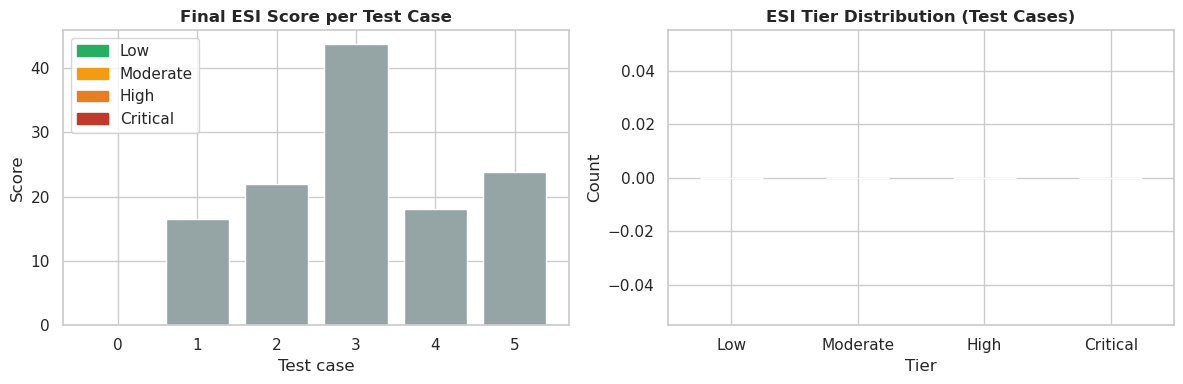

In [97]:
# 5.2 Score distribution across test cases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tier_colors = {'Low': '#27ae60', 'Moderate': '#f39c12', 'High': '#e67e22', 'Critical': '#c0392b'}
colors = [tier_colors.get(r['Got'], '#95a5a6') for _, r in results_df.iterrows()]

axes[0].bar(range(len(results_df)), results_df['Score'], color=colors, edgecolor='white')
axes[0].set_title('Final ESI Score per Test Case', fontweight='bold')
axes[0].set_xlabel('Test case')
axes[0].set_ylabel('Score')
patches = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
axes[0].legend(handles=patches, loc='upper left')

# Tier distribution
results_df['Got'].value_counts().reindex(['Low','Moderate','High','Critical'], fill_value=0).plot(
    kind='bar', ax=axes[1],
    color=[tier_colors.get(t, '#95a5a6') for t in ['Low','Moderate','High','Critical']],
    edgecolor='white'
)
axes[1].set_title('ESI Tier Distribution (Test Cases)', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [98]:
# 5.3 Alias recall — what fraction of gynaecology notes hit at least one alias?
sample_notes = gyn_clean['clean_transcription'].sample(min(100, len(gyn_clean)), random_state=42)

hits = sample_notes.apply(lambda t: len(alias_match(t)) > 0)
recall = hits.mean() * 100

print(f'Alias recall on {len(sample_notes)} gynaecology notes: {recall:.1f}%')
print(f'(Target: ≥ 85%)')
print(f'Status: {" PASS" if recall >= 85 else " FAIL — expand symptom_aliases.json"}')

# Notes with zero alias hits — inspect to find gaps
zero_hit_notes = sample_notes[~hits]
print(f'\nNotes with zero alias matches: {len(zero_hit_notes)}')
if len(zero_hit_notes) > 0:
    print('Sample (to identify missing aliases):')
    for note in zero_hit_notes.head(3):
        print(f'  → {note[:120]}...')

Alias recall on 100 gynaecology notes: 32.0%
(Target: ≥ 85%)
Status:  FAIL — expand symptom_aliases.json

Notes with zero alias matches: 68
Sample (to identify missing aliases):
  → PROCEDURE: , Laparoscopy with ablation of endometriosis.,DIAGNOSIS: , Endometriosis.,ANESTHESIA:, General.,ESTIMATED BLO...
  → FINAL DIAGNOSES:, Delivered pregnancy, cholestasis of pregnancy, fetal intolerance to labor, failure to progress.,PROCED...
  → PREOPERATIVE DIAGNOSES:,1. Cervical intraepithelial neoplasia grade-III status post conization with poor margins.,2. Rec...


---
## Phase 6 — Deployment

In [ ]:
# 6.1 Export assess_symptoms as a standalone module
# The nlp_pipeline.py file is the production version.
# Confirm it's callable:

demo = assess_symptoms(
    text='Nina maumivu makali ya hedhi, bloating, na maumivu wakati wa tendo la ndoa.',
    duration_weeks=36,
    history_flags=['infertility'],
    use_ner=True
)

print('=== DEMO OUTPUT ===')
print(f'ESI Tier         : {demo["esi_tier"]}')
print(f'Raw Score        : {demo["raw_score"]}')
print(f'Final Score      : {demo["final_score"]}')
print(f'Symptoms matched : {[m["id"] for m in demo["matched_symptoms"]]}')
print(f'Modifiers        : {demo["modifiers_applied"]}')
print(f'Auto-escalated   : {demo["auto_escalated"]}')
print(f'Refer urgency    : {demo["refer_urgency"]}')

In [ ]:
# 6.2 API integration — how the Node.js backend calls this
print('''
=== Node.js Integration ===

1. Start the Flask API:
   python nlp_api.py
   → listening on http://localhost:5050

2. From Node.js / React fetch:
   POST http://localhost:5050/assess
   Body: {
     "text":           "patient symptom text here",
     "duration_weeks": 24,
     "history_flags":  ["infertility"]
   }

3. Response:
   {
     "esi_tier":         "High",
     "final_score":      18.4,
     "refer_urgency":    "Urgent — within 1–2 weeks",
     "matched_symptoms": [...],
     ...
   }

Friday demo flow:
  User types → React form → POST /assess → ESI badge + referral card
''')

In [ ]:
# 6.3 Friday deliverable checklist
checklist = [
    ('symptoms.json',           'Weighted symptom list (38+ symptoms)'),
    ('scoring_rules.json',      'ESI tiers + duration + history modifiers'),
    ('symptom_aliases.json',    '108+ aliases (English, Swahili, Kenyan English)'),
    ('nlp_pipeline.py',         'assess_symptoms() — 3-layer pipeline'),
    ('nlp_api.py',              'Flask API on port 5050'),
    ('endo_train_320.csv',      'Training split — 320 gynaecology notes'),
    ('endo_val_80.csv',         'Validation split — 80 gynaecology notes'),
    ('This notebook',           'CRISP-DM documentation + evaluation'),
]

print('=== Friday Deliverable Checklist ===')
for item, desc in checklist:
    exists = Path(item.replace('This notebook', 'EndoScan_AI_NLP_CRISPDM.ipynb')).exists()
    status = '✅' if exists else '⏳'
    print(f'{status}  {item:35} — {desc}')